## HW_2__NLP_Lecture_NB_DomainShift_RU_ipynb

# Домашка

## Часть A — Domain shift / распределения
1) Выберите датасет на русском  языке и два домена (2 темы из одного датасета, или 2 датасета HF, или свои тексты. Вариант датасета: https://huggingface.co/datasets/data-silence/rus_news_classifier).
2) Посчитайте **top-30 log-odds** токенов (в обе стороны).
3) Нарисуйте хотя бы 2 графика распределений (на выбор):
   - длина документов,
   - Zipf (частоты топ-100 токенов),
   - доля чисел/пунктуации,
   - размер словаря.
4) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
5) Напишите 5–10 наблюдений: что изменилось и почему.

## Часть B — Наивный Байес + оценка
1) Выберите 2 автора (русский).
2) Нарежьте тексты на чанки (80–300 токенов).
3) Обучите MultinomialNB и отчитайтесь:
   - confusion matrix,
   - precision/recall/F1.
4) Покажите **top-20 важнейших токенов** на основе Δ(w).
5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.



In [59]:
# Базовые библиотеки
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from typing import List, Tuple

from datasets import load_dataset

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Вспомогательные функции



In [25]:
TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(text.lower())

def chunk_tokens(tokens: List[str], chunk_size: int = 200, min_frac: float = 0.5) -> List[str]:
    """Режем на чанки фиксированной длины; хвост сохраняем, если он >= min_frac*chunk_size."""
    chunks = []
    min_len = int(chunk_size * min_frac)
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))
    return chunks

def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}
    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)
    return deltas

def top_log_odds_words(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(simple_tokenize(t))
    for t in texts_b:
        cb.update(simple_tokenize(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

def plot_length_hist(texts: List[str], title: str):
    lens = [len(simple_tokenize(t)) for t in texts]
    plt.figure()
    plt.hist(lens, bins=50, alpha=0.75)
    plt.title(title)
    plt.xlabel("длина документа (токены)")
    plt.ylabel("кол-во")
    plt.show()


# Часть A — Domain shift и различия распределений
# A1) Был выбран датасет с категориями: https://huggingface.co/datasets/data-silence/rus_news_classifier

In [26]:
ds = load_dataset("data-silence/rus_news_classifier")
ds

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})

In [27]:
print(ds["train"].features)
print(ds["train"][0].keys())
print("Пример текста:\n", ds["train"][1]["news"][:150])
print("label:", ds["train"][1]["labels"])

{'news': Value('string'), 'labels': Value('int32')}
dict_keys(['news', 'labels'])
Пример текста:
 В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров. Об этом сообщает издание Windows Latest. Журналисты выяснили, что
label: 7


Выбор 2-х самых популярных тем из датасета

In [28]:
labels = [ex["labels"] for ex in ds["train"]]
cnt = Counter(labels)
print("Две самые популярные темы", cnt.most_common(2) )

Две самые популярные темы [(4, 7993), (1, 6277)]


categories_translator =
{'climate': 0,
 **'conflicts': 1,**
 'culture': 2,
 'economy': 3,
 **'gloss': 4,**
 'health': 5,
 'politics': 6,
 'science': 7,
 'society': 8,
 'sports': 9,
 'travel': 10}

In [29]:
label_gloss, label_conflicts = [x for x,_ in cnt.most_common(2)]
label_gloss, label_conflicts

(4, 1)

 Несколько примеров из каждого класса

In [30]:
text_gloss = [i["news"] for i in ds["train"] if i["labels"]==label_gloss]
text_conflicts = [i["news"] for i in ds["train"] if i["labels"]==label_conflicts]
print(text_gloss[3][:150])
print(text_conflicts[2][:150])

Российская телеведущая Ксении Собчак отправилась к друзьям на шашлыки в откровенном наряде. Соответствующая публикация (на данный момент она удалена) 
Полиция задержала 17-летнего жителя Амурской области, опубликовавшего в соцсети фейковое сообщение о готовящемся теракте в школе Благовещенска. Об это


# A2) top-30 log-odds токенов (в обе стороны).

In [31]:
cnt_gloss = Counter()
for t in text_gloss:
  cnt_gloss.update(simple_tokenize(t))

N_tokens = sum(cnt_gloss.values())  # tokens = все употребления
V_types = len(cnt_gloss)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-30
top30 = cnt_gloss.most_common(30)
top30[:10]

Tokens (всего словоупотреблений): 1,481,574
Types  (уникальных слов):        117,026


[('в', 70758),
 ('и', 42284),
 ('на', 34295),
 ('что', 19939),
 ('с', 18698),
 ('не', 12524),
 ('по', 12399),
 ('из', 10105),
 ('за', 8147),
 ('она', 6724)]

In [32]:
cnt_conflicts = Counter()
for t in text_conflicts:
  cnt_conflicts.update(simple_tokenize(t))

N_tokens = sum(cnt_conflicts.values())  # tokens = все употребления
V_types = len(cnt_conflicts)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-30
top30 = cnt_conflicts.most_common(30)
top30[:10]

Tokens (всего словоупотреблений): 890,337
Types  (уникальных слов):        69,649


[('в', 48535),
 ('и', 19182),
 ('на', 18175),
 ('что', 12659),
 ('по', 12468),
 ('с', 9544),
 ('из', 6207),
 ('об', 5632),
 ('этом', 5526),
 ('не', 5362)]

In [33]:
pos, neg = top_log_odds_words(text_gloss, text_conflicts, top_n=30, alpha=0.1)
print("Топ-слова для gloss (против conf):")
display(pd.DataFrame(pos, columns=["word", "Δ(gloss-conf)"]))
print("Топ-слова для conf (против gloss):")
display(pd.DataFrame(neg, columns=["word", "Δ(gloss-conf)"]))

Топ-слова для gloss (против conf):


,word,Δ(gloss-conf)
0,знаменитость,9.063841
1,откровенном,8.216636
2,предстала,8.034347
3,кардашьян,8.024497
4,бикини,7.963266
5,позирует,7.877612
6,манекенщица,7.870709
7,лайков,7.847349
8,поклонники,7.808799
9,декольте,7.783929


Топ-слова для conf (против gloss):


,word,Δ(gloss-conf)
0,идлибе,-7.585393
1,магнитудой,-7.411599
2,ланцет,-7.317388
3,поражать,-7.163420
4,кабула,-7.124250
5,камикадзе,-7.069517
6,разрушений,-6.901440
7,рсзо,-6.901440
8,залпового,-6.867595
9,ксир,-6.850234


## А3) 2 графика распределений:
длина документов,
Zipf (частоты топ-100 токенов),

In [34]:
label_names = [
    "climate", "conflicts", "culture", "economy", "gloss",
    "health", "politics", "science", "society", "sports", "travel"
]
df_len = pd.DataFrame({
    "len_tokens": [len(simple_tokenize(i)) for i in ds["train"]["news"]],
    "domain": [label_names[j] for j in ds["train"]["labels"]]
})

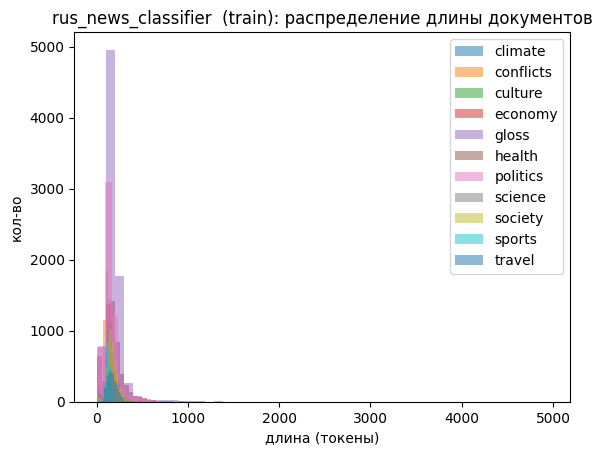

In [35]:
for dom, g in df_len.groupby("domain"):
    plt.hist(g["len_tokens"], bins=50, alpha=0.5, label=dom)

plt.legend()
plt.title("rus_news_classifier  (train): распределение длины документов")
plt.xlabel("длина (токены)")
plt.ylabel("кол-во")
plt.show()

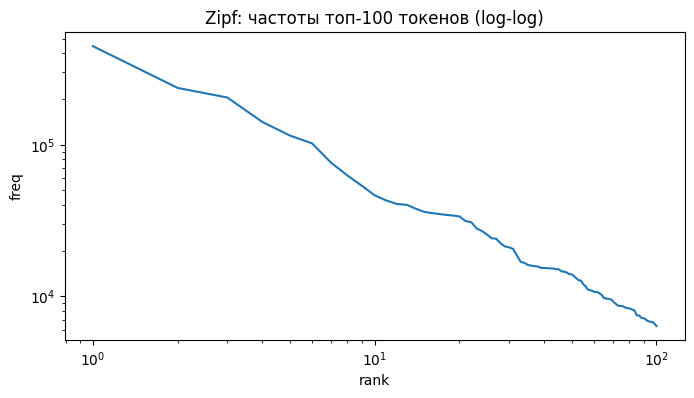

,token,count
0,в,446720
1,и,236727
2,на,204749
3,что,141046
4,с,114927
5,по,101963
6,не,76111
7,из,62720
8,за,53673
9,для,46360


In [36]:
total_counts = Counter()

for text in ds["train"]["news"]:
    total_counts.update(simple_tokenize(text))

top100 = total_counts.most_common(100)
ranks = np.arange(1, 101)
freqs = np.array([c for _,c in top100])

plt.figure(figsize=(8,4))
plt.plot(ranks, freqs)
plt.yscale("log")
plt.xscale("log")
plt.title("Zipf: частоты топ-100 токенов (log-log)")
plt.xlabel("rank")
plt.ylabel("freq")
plt.show()

pd.DataFrame(top100, columns=["token","count"]).head(20)

## А4) Добавление лемматизацию, n-граммы, стоп-слова, и сравние важных токенов

In [37]:
!pip -q install pymorphy3 pymorphy3-dicts-ru

In [38]:
import pymorphy3
import nltk
from nltk.corpus import stopwords

In [39]:
ru_stop = set(stopwords.words("russian"))
morph = pymorphy3.MorphAnalyzer()

In [40]:
from functools import lru_cache

@lru_cache(maxsize=200_000)
def lemma_cached(w: str) -> str:
    return morph.parse(w)[0].normal_form

def tokenize_lemmas(text: str) -> List[str]:
    token = []
    words = simple_tokenize(text)
    for w in words:
        if w in ru_stop:
            continue
        lemma = lemma_cached(w)
        if lemma in ru_stop:
            continue
        token.append(lemma)
    return token

def add_ngrams(tokens: List[str], n: int = 2) -> List[str]:
    if n <= 1:
        return tokens
    out = list(tokens)
    for k in range(2, n + 1):
        for i in range(len(tokens) - k + 1):
            out.append(" ".join(tokens[i:i+k]))   # или "_".join(...)
    return out

def top_log_odds_words_lemmas(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(tokenize_lemmas(t))
    for t in texts_b:
        cb.update(tokenize_lemmas(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

In [41]:
print(tokenize_lemmas(text_gloss[0])[:30])
print(len(tokenize_lemmas(text_gloss[0])))

['блогерш', 'домохозяйка', 'линда', 'андраде', 'раскрыть', 'требование', 'жених', 'миллионер', 'заключение', 'брак', 'соответствовать', 'публикация', 'появиться', 'аккаунт', 'который', 'насчитывать', 'тысяча', 'подписчик', 'жить', 'дубай', 'летний', 'американка', 'рассказать', 'прежде', 'согласиться', 'выйти', 'замуж', 'богатый', 'возлюбить', 'выдвинуть']
101


In [42]:
pos, neg = top_log_odds_words_lemmas(text_gloss, text_conflicts, top_n=30, alpha=0.1)
print("Топ-слова для gloss (против conf):")
display(pd.DataFrame(pos, columns=["word", "Δ(gloss-conf)"]))
print("Топ-слова для conf (против gloss):")
display(pd.DataFrame(neg, columns=["word", "Δ(gloss-conf)"]))

Топ-слова для gloss (против conf):


,word,Δ(gloss-conf)
0,модный,8.659628
1,макияж,8.341753
2,манекенщица,8.271290
3,кардашьян,8.058056
4,юбка,8.042217
5,гардероб,7.988937
6,бикини,7.988937
7,лайковый,7.873020
8,декольте,7.809600
9,каблук,7.728318


Топ-слова для conf (против gloss):


,word,Δ(gloss-conf)
0,гиперзвуковой,-7.810850
1,ланцет,-7.472023
2,авианосец,-7.071587
3,высокоточный,-7.057813
4,камикадзе,-7.043846
5,диверсант,-7.015313
6,рсзый,-6.875768
7,надводный,-6.858989
8,противоракетный,-6.841924
9,циркон,-6.841924


## А5) Напишите 5 наблюдений:
- после лемматизации стали популярны более простые слова, не названия
- лемматизация без кэширования на больших текстах длительна
- без стоп-слов самые популярные слова это союзы
-  n-граммы не попали в сравнение glass и conf
- при сравнение слов glass и conf  в топ 30 каждое слово можно точно отнести к каждой теметики

## Часть B — Наивный Байес, метрики и перенос (prose → poetry)
B1) Выберить 2 автора (русский).
Александр Пушкин
- проза: Повести покойного Ивана Петровича Белкина
- поэзия: 3-cтихотворения Александра Пушкина

Николай Гоголь
- проза: Вечера на хуторе близ Диканьки
- поэзия: Ганц Кюхельгартен

In [43]:
import requests

In [44]:
YANDEX_URL = "https://disk.yandex.ru/d/jgpiPGPAZ6W7rg"

In [51]:
def download_yandex_text(YANDEX_URL:str) -> str:
  api_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download"
  params = {"public_key": YANDEX_URL}
  response = requests.get(api_url, params=params, timeout=30)
  data = response.json()
  raw = requests.get(data.get('href'),timeout=30).content
  return raw.decode("UTF-8")

In [53]:
pushkin_prose = download_yandex_text("https://disk.yandex.ru/d/1nUrqQobuSr2Jg")
pushkin_poetry = download_yandex_text("https://disk.yandex.ru/d/bTS5rlWsUsKdww")
gogal_prose = download_yandex_text("https://disk.yandex.ru/d/nThp_jS1gq7UhA")
gogal_poetry =  download_yandex_text("https://disk.yandex.ru/d/09BVN_Me-PgH8Q")

print(pushkin_prose[:200]+'\n')
print(pushkin_poetry[:200]+'\n')
print(gogal_prose[:200]+'\n')
print(gogal_poetry[:200]+'\n')

     Взявшись хлопотать об издании Повестей И. П. Белкина, предлагаемых ныне
публике, мы желали к оным присовокупить хотя краткое жизнеописание покойного
автора,  и  тем  отчасти удовлетворить справ

Я помню чудное мгновенье:
Передо мной явилась ты,
Как мимолетное виденье,
Как гений чистой красоты.
В томленьях грусти безнадежной,
В тревогах шумной суеты,
Звучал мне долго голос нежный
И снил

     "Это  что  за  невидаль: "Вечера на хуторе близ Диканьки"?
Что это за "Вечера"? И швырнул в свет какой-то пасечник!  Слава
богу!  еще  мало  ободрали  гусей  на  перья и извели тряпья на
бумаг

Италия — роскошная страна!
По ней душа и стонет и тоскует.
Она вся рай, вся радости полна,
И в ней любовь роскошная веснует.
Бежит, шумит задумчиво волна
И берега чудесные целует;
В ней небеса п



# B2) Режем на чанки

In [68]:

CHUNK_SIZE = 80  # меньше -> больше документов; попробуйте 80..200

def make_chunks(text: str, chunk_size: int) -> List[str]:
    toks = simple_tokenize(text)
    return chunk_tokens(toks, chunk_size=chunk_size, min_frac=0.5)

pushkin_prose_chunks = make_chunks(pushkin_prose, CHUNK_SIZE)
gogal_prose_chunks = make_chunks(gogal_prose, CHUNK_SIZE)

pushkin_poetry_chunks = make_chunks(pushkin_poetry, CHUNK_SIZE)
gogal_poetry_chunks = make_chunks(gogal_poetry, CHUNK_SIZE)

print("Чанки (проза):", len(pushkin_prose_chunks), len(gogal_prose_chunks))
print("Чанки (поэзия):", len(pushkin_poetry_chunks), len(gogal_poetry_chunks))

# метки: 0 = Poe, 1 = Wilde
X_prose = pushkin_prose_chunks + gogal_prose_chunks
y_prose = np.array([0]*len(pushkin_prose_chunks) + [1]*len(gogal_prose_chunks))

X_poetry = pushkin_poetry_chunks + gogal_poetry_chunks
y_poetry = np.array([0]*len(pushkin_poetry_chunks) + [1]*len(gogal_poetry_chunks))

author_names = ["Pushkin", "Gogal"]


Чанки (проза): 238 326
Чанки (поэзия): 3 5


## B3) Обучите MultinomialNB и отчитайтесь

In [60]:
# Train/Valid split (внутридоменный: проза → проза)

Xtr, Xva, ytr, yva = train_test_split(
    X_prose, y_prose, test_size=0.25, random_state=RANDOM_STATE, stratify=y_prose
)

print("Train chunks:", len(Xtr), "Valid chunks:", len(Xva))

Train chunks: 423 Valid chunks: 141


In [63]:
# B4-baseline) Multinomial NB (counts) — без предобработки

nb_counts_base = Pipeline([
    ("vec", CountVectorizer(
        # всё по умолчанию:
        # lowercase=True, token_pattern=...,
        # stop_words=None, min_df=1, max_df=1.0, ngram_range=(1,1)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_base.fit(Xtr, ytr)
pred_va_base = nb_counts_base.predict(Xva)

print("BASE In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va_base))
print(classification_report(yva, pred_va_base, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va_base))


BASE In-domain (PROSE→PROSE) accuracy: 0.9929078014184397
              precision    recall  f1-score   support

     Pushkin       1.00      0.98      0.99        60
       Gogal       0.99      1.00      0.99        81

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141

Confusion matrix:
 [[59  1]
 [ 0 81]]


По confusion matrix:
- Пушкин/Пушкина TP модель предсказала 59 раз верно, Пушкин/Гоголь FN 1 раз неверно
- Гогаль/Пушкин FP модель предсказала 0 раз неверно, Гогаль/Гогаль TN 89 раз верно

precision = TP / (TP + FP) = 1.00

recall = TP / (TP + FN) = 0.98


F1 = 2 · precision · recall / (precision + recall) = 0.99

## B4) Покажите top-20 важнейших токенов на основе Δ(w).

In [70]:
#  Самые важные токены для NB: Δ(w)=logP(w|Pushkin)-logP(w|Gogal)

vec = nb_counts_base.named_steps["vec"]
clf = nb_counts_base.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 30
top_pushkin = np.argsort(-delta)[:top_n]
top_gogal = np.argsort(delta)[:top_n]  # самые отрицательные

df_pushkin = pd.DataFrame({"token": feature_names[top_pushkin], "Δ": delta[top_pushkin]})
df_gogal = pd.DataFrame({"token": feature_names[top_gogal], "Δ": delta[top_gogal]})

print("Топ-токены для Пушкина")
display(df_pushkin)
print("Топ-токены для Гогаль")
display(df_gogal)


Топ-токены для Пушкина


,token,Δ
0,сильвио,6.119406
1,лиза,6.088728
2,алексей,6.057080
3,всь,5.881808
4,смотритель,5.842740
5,дуня,5.569561
6,гавриловна,5.398692
7,марья,5.398692
8,владимир,5.334567
9,петрович,5.266047


Топ-токены для Гогаль


,token,Δ
0,дед,-5.676674
1,левко,-5.389823
2,немного,-5.167510
3,черт,-5.167510
4,черевик,-4.986018
5,парубок,-4.934986
6,пан,-4.934986
7,хату,-4.934986
8,деда,-4.764117
9,ганна,-4.764117


## B5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.



Добавим более «практичную» предобработку:
- удаление стоп-слов (встроенный список английских),
- фильтрация слишком частых слов `max_df`,
- фильтрация редких `min_df`,
- добавим биграммы (1,2) — часто помогает на авторстве.


In [73]:
@lru_cache(maxsize=200_000)
def lemma_cached(w: str) -> str:
    return morph.parse(w)[0].normal_form

def tokenize_lemmas(text: str) -> List[str]:
    tokens = []
    for w in simple_tokenize(text.lower()):
        if w in ru_stop:
            continue
        lemma = lemma_cached(w)
        if lemma in ru_stop:
            continue
        tokens.append(lemma)
    return tokens

vec = CountVectorizer(
    tokenizer=tokenize_lemmas,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

In [75]:
# B4) Multinomial NB (counts) + улучшенная предобработка

nb_counts = Pipeline([
    ("vec", vec),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts.fit(Xtr, ytr)
pred_va = nb_counts.predict(Xva)

print("In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va))
print(classification_report(yva, pred_va, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va))


In-domain (PROSE→PROSE) accuracy: 0.9929078014184397
              precision    recall  f1-score   support

     Pushkin       0.98      1.00      0.99        60
       Gogal       1.00      0.99      0.99        81

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141

Confusion matrix:
 [[60  0]
 [ 1 80]]


In [76]:
#  Самые важные токены для NB: Δ(w)=logP(w|Pushkin)-logP(w|Gogal)

vec = nb_counts.named_steps["vec"]
clf = nb_counts.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 30
top_pushkin = np.argsort(-delta)[:top_n]
top_gogal = np.argsort(delta)[:top_n]  # самые отрицательные

df_pushkin = pd.DataFrame({"token": feature_names[top_pushkin], "Δ": delta[top_pushkin]})
df_gogal = pd.DataFrame({"token": feature_names[top_gogal], "Δ": delta[top_gogal]})

print("Топ-токены для Пушкина")
display(df_pushkin)
print("Топ-токены для Гогаль")
display(df_gogal)


Топ-токены для Пушкина


,token,Δ
0,смотритель,6.347383
1,лиза,6.273458
2,алексей,6.220953
3,сильвио,6.106869
4,петрович,5.943105
5,дуня,5.943105
6,гаврилович,5.943105
7,всь,5.869271
8,владимир,5.702913
9,иван петрович,5.702913


Топ-токены для Гогаль


,token,Δ
0,дед,-6.110346
1,хата,-6.042639
2,парубок,-5.713843
3,левко,-5.402360
4,свитка,-5.297368
5,черевик,-5.297368
6,земля,-5.259770
7,немного,-5.180046
8,пан,-5.137667
9,ведьма,-5.093412


## B6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.

In [77]:
# B6) Domain shift: обучаемся на прозе, тестируемся на поэзии

pred_poetry = nb_counts.predict(X_poetry)

print("Domain shift (PROSE→POETRY) accuracy:", accuracy_score(y_poetry, pred_poetry))
print(classification_report(y_poetry, pred_poetry, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_poetry, pred_poetry))


Domain shift (PROSE→POETRY) accuracy: 0.75
              precision    recall  f1-score   support

     Pushkin       1.00      0.33      0.50         3
       Gogal       0.71      1.00      0.83         5

    accuracy                           0.75         8
   macro avg       0.86      0.67      0.67         8
weighted avg       0.82      0.75      0.71         8

Confusion matrix:
 [[1 2]
 [0 5]]


По confusion matrix:
- Пушкин/Пушкина TP модель предсказала 1 раз верно, Пушкин/Гоголь FN 2 раз неверно
- Гогаль/Пушкин FP модель предсказала 0 раз неверно, Гогаль/Гогаль TN 2 раз верно

precision = TP / (TP + FP) = 1.00

recall = TP / (TP + FN) = 0.33


F1 = 2 · precision · recall / (precision + recall) = 0.50

recall Модель стала хуже угадывать Пушкина, чем Гогаля на всех элементах класса


precision Пушкина принимает за Гогаля
